In [1]:
import pandas as pd
import numpy as np
import torch
from torch.nn.utils.rnn import pad_sequence
from sklearn.preprocessing import MinMaxScaler
from sentence_transformers import SentenceTransformer

# === Load CSVs ===
sentiment_df = pd.read_csv("sentiment_replies.csv")
topic_df = pd.read_csv("topic.csv")

# === Clean sentiment_replies.csv ===
sentiment_df['dateTime'] = (
    sentiment_df['dateTime'].astype(str).str.replace('»', '', regex=False).str.strip()
)
sentiment_df['dateTime'] = pd.to_datetime(sentiment_df['dateTime'], format='mixed')

sentiment_df['postcount'] = (
    sentiment_df['postcount'].astype(str)
    .str.extract(r'(\d[\d,]*)')[0]
    .str.replace(',', '', regex=False)
    .astype(float)
)

sentiment_df['author'] = sentiment_df['author'].astype(str).str.strip().str.lower()
sentiment_df['member group'] = sentiment_df['member group'].astype(str).str.strip().str.lower()

sentiment_df['reply_index'] = (
    sentiment_df['threadDetails'].astype(str)
    .str.extract(r'Reply\s+#(\d+)', expand=False)
    .fillna(0).astype(int)
)

sentiment_columns = ['pos', 'neg', 'neu', 'compound', 'textblob_sentiment']
for col in sentiment_columns:
    sentiment_df[col] = pd.to_numeric(sentiment_df[col], errors='coerce')

sentiment_df_cleaned = sentiment_df.dropna(subset=['dateTime', 'postId'])
sentiment_df_cleaned = sentiment_df_cleaned.drop_duplicates(subset=['postId'])
sentiment_df_cleaned.reset_index(drop=True, inplace=True)

# === Clean topic.csv ===
topic_df['views'] = (
    topic_df['views'].astype(str)
    .str.replace(r'\s+', '', regex=True)
    .str.replace(r'\D', '', regex=True)
    .replace('', np.nan)
    .astype(float)
)

topic_df['datePost'] = (
    topic_df['datePost'].astype(str)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)
topic_df['datePost'] = pd.to_datetime(topic_df['datePost'], format='mixed')

topic_df['replies'] = pd.to_numeric(topic_df['replies'], errors='coerce').fillna(0).astype(int)

for col in ['topic', 'startedBy', 'latestBy']:
    topic_df[col] = topic_df[col].astype(str).str.strip().str.lower().replace('nan', 'unknown')

topic_df_cleaned = topic_df.dropna(subset=['id', 'datePost']).drop_duplicates(subset=['id']).reset_index(drop=True)

# === Merge ===
merged_df = sentiment_df_cleaned.merge(
    topic_df_cleaned, left_on="connecting_id", right_on="id",
    suffixes=('_reply', '_topic')
)

merged_df = merged_df.sort_values(by=["connecting_id", "dateTime"]).reset_index(drop=True)
merged_df['delta_t'] = merged_df.groupby('connecting_id')['dateTime'].diff().dt.total_seconds() / 3600
merged_df['delta_t'] = merged_df['delta_t'].fillna(0)

# === Create feature_df with replyMess and label ===
feature_df = merged_df[[
    'connecting_id', 'postId', 'dateTime', 'replyMess', 'delta_t',
    'compound', 'textblob_sentiment', 'reply_index',
    'postcount', 'views', 'replies', 'topic'
]].copy()

# === Add label (1 if next reply is within 24h) ===
feature_df['label'] = 0
grouped = feature_df.groupby("connecting_id")

for thread_id, group in grouped:
    times = group['dateTime'].values
    indices = group.index.values
    for i in range(len(times) - 1):
        current_time = times[i]
        future_times = times[i+1:]
        time_gaps = (future_times - current_time) / np.timedelta64(1, 'h')
        if any(time_gaps <= 24):
            feature_df.loc[indices[i], 'label'] = 1

# === Step 1: Generate SBERT embeddings for replyMess ===
print("Generating SBERT embeddings...")
sbert = SentenceTransformer('all-MiniLM-L6-v2')
reply_texts = feature_df['replyMess'].astype(str).tolist()
reply_embeddings = sbert.encode(reply_texts, show_progress_bar=True)  # shape: (num_posts, 384)

# === Step 2: Normalize numeric features ===
feature_cols = ['delta_t', 'compound', 'textblob_sentiment', 'reply_index', 'postcount', 'views', 'replies']
scaler = MinMaxScaler()
feature_df[feature_cols] = scaler.fit_transform(feature_df[feature_cols])
X_structured = feature_df[feature_cols].values  # shape: (num_posts, 7)

# === Step 3: Concatenate structured + SBERT embeddings ===
X_combined = np.hstack((X_structured, reply_embeddings))  # shape: (num_posts, 391)

# === Step 4: Group sequences and labels by thread ===
sequences = []
label_sequences = []

# === Step 4b: Add lambda_target (time until next reply) ===
feature_df = feature_df.sort_values(by=["connecting_id", "dateTime"]).reset_index(drop=True)
feature_df['lambda_target'] = (
    feature_df.groupby('connecting_id')['dateTime']
    .transform(lambda x: x.shift(-1) - x)
    .dt.total_seconds() / 3600
)

# === Step 4c: Add count_target (number of replies in next 24 hours) ===
def count_replies_within_24h(group):
    times = group['dateTime'].tolist()
    counts = []
    for i, t in enumerate(times):
        count = sum((t < t2 <= t + pd.Timedelta(hours=24)) for t2 in times[i+1:])
        counts.append(count)
    return pd.Series(counts, index=group.index)

feature_df['count_target'] = feature_df.groupby('connecting_id').apply(count_replies_within_24h).reset_index(level=0, drop=True)

# === Step 4d: Group lambda and count into padded sequences ===
lambda_sequences = []
count_sequences = []

for thread_id, group in feature_df.groupby("connecting_id"):
    lambda_tensor = torch.tensor(group['lambda_target'].fillna(0).values, dtype=torch.float32)
    count_tensor = torch.tensor(group['count_target'].fillna(0).values, dtype=torch.float32)
    lambda_sequences.append(lambda_tensor)
    count_sequences.append(count_tensor)

padded_lambda = pad_sequence(lambda_sequences, batch_first=True)
padded_count = pad_sequence(count_sequences, batch_first=True)



for thread_id, group in feature_df.groupby("connecting_id"):
    indices = group.index
    features_tensor = torch.tensor(X_combined[indices], dtype=torch.float32)
    labels_tensor = torch.tensor(group['label'].values, dtype=torch.float32)
    sequences.append(features_tensor)
    label_sequences.append(labels_tensor)



# === Step 5: Pad sequences ===
padded_inputs = pad_sequence(sequences, batch_first=True)      # (num_threads, max_seq_len, 391)
padded_labels = pad_sequence(label_sequences, batch_first=True)  # (num_threads, max_seq_len)

# === Done ===
print("✅ Final SBERT input shape:", padded_inputs.shape)
print("✅ Final label shape:", padded_labels.shape)


Generating SBERT embeddings...


Batches:   0%|          | 0/217 [00:00<?, ?it/s]

C:\Users\shubb\AppData\Local\Temp\ipykernel_12952\1164738609.py:132: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  feature_df['count_target'] = feature_df.groupby('connecting_id').apply(count_replies_within_24h).reset_index(level=0, drop=True)


✅ Final SBERT input shape: torch.Size([730, 50, 391])
✅ Final label shape: torch.Size([730, 50])


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from sklearn.metrics import precision_recall_fscore_support, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

class DecayedAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.u = nn.Parameter(torch.randn(hidden_dim))
        self.w = nn.Parameter(torch.tensor(1.0))

    def forward(self, h, times, mask=None):
        B, T, H = h.shape
        time_diffs = times.unsqueeze(2) - times.unsqueeze(1)
        gamma = torch.exp(-self.w * time_diffs.clamp(min=0))
        u_proj = torch.tanh(torch.matmul(h, self.u))
        e = u_proj.unsqueeze(2) * gamma
        if mask is not None:
            mask = mask.unsqueeze(1).expand(B, T, T)
            e = e.masked_fill(~mask, float('-inf'))
        attn_weights = F.softmax(e, dim=2)
        context = torch.bmm(attn_weights, h)
        return context, attn_weights

class BehavioralPointProcessModel(nn.Module):
    def __init__(self, input_dim=391, hidden_dim=128):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.attn_time = DecayedAttention(hidden_dim)
        self.attn_reply = DecayedAttention(hidden_dim)
        self.attn_count = DecayedAttention(hidden_dim)
        self.time_head = nn.Sequential(nn.Linear(hidden_dim, 1), nn.Softplus())
        self.reply_head = nn.Sequential(nn.Linear(hidden_dim, 1), nn.Sigmoid())
        self.count_head = nn.Sequential(nn.Linear(hidden_dim, 1), nn.ReLU())

    def forward(self, x, times, mask):
        h, _ = self.gru(x)
        s_time, attn_time = self.attn_time(h, times, mask)
        s_reply, attn_reply = self.attn_reply(h, times, mask)
        s_count, attn_count = self.attn_count(h, times, mask)
        lambda_t = self.time_head(s_time).squeeze(-1)
        pi_reply = self.reply_head(s_reply).squeeze(-1)
        count_t = self.count_head(s_count).squeeze(-1)
        return {
            'lambda': lambda_t,
            'reply_prob': pi_reply,
            'count': count_t,
            'attn_time': attn_time,
            'attn_reply': attn_reply,
            'attn_count': attn_count
        }

def train_multitask(model, X_train, y_reply, y_lambda, y_count, t_train, X_val, y_reply_val, y_lambda_val, y_count_val, t_val, num_epochs=20, lr=1e-3, patience=3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    mask_train = (X_train.sum(dim=-1) != 0)
    mask_val = (X_val.sum(dim=-1) != 0)

    X_train, y_reply, y_lambda, y_count, t_train, mask_train = X_train.to(device), y_reply.to(device), y_lambda.to(device), y_count.to(device), t_train.to(device), mask_train.to(device)
    X_val, y_reply_val, y_lambda_val, y_count_val, t_val, mask_val = X_val.to(device), y_val.to(device), lambda_val.to(device), count_val.to(device), t_val.to(device), mask_val.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5, verbose=True)
    bce_loss = nn.BCELoss(reduction='none')
    mse_loss = nn.MSELoss(reduction='none')

    best_loss = float('inf')
    patience_counter = 0

    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        output = model(X_train, t_train, mask_train)
        pred_reply = output['reply_prob']
        pred_lambda = output['lambda']
        pred_count = output['count']

        loss_reply = (bce_loss(pred_reply, y_reply) * mask_train).sum() / mask_train.sum()
        loss_lambda = (mse_loss(pred_lambda, y_lambda) * mask_train).sum() / mask_train.sum()
        loss_count = (mse_loss(pred_count, y_count) * mask_train).sum() / mask_train.sum()
        total_loss = loss_reply + loss_lambda + loss_count
        total_loss.backward()
        optimizer.step()
        scheduler.step(total_loss)

        model.eval()
        with torch.no_grad():
            val_output = model(X_val, t_val, mask_val)
            val_pred_reply = val_output['reply_prob']
            val_pred_lambda = val_output['lambda']
            val_pred_count = val_output['count']

            val_loss_reply = (bce_loss(val_pred_reply, y_reply_val) * mask_val).sum() / mask_val.sum()
            val_loss_lambda = (mse_loss(val_pred_lambda, y_lambda_val) * mask_val).sum() / mask_val.sum()
            val_loss_count = (mse_loss(val_pred_count, y_count_val) * mask_val).sum() / mask_val.sum()
            val_total_loss = val_loss_reply + val_loss_lambda + val_loss_count

            pred_labels = (val_pred_reply > 0.5).float()
            flat_preds = pred_labels[mask_val].cpu().numpy()
            flat_true = y_reply_val[mask_val].cpu().numpy()
            precision, recall, f1, _ = precision_recall_fscore_support(flat_true, flat_preds, average='binary', zero_division=0)

            mae_lambda = mean_absolute_error(y_lambda_val[mask_val].cpu(), val_pred_lambda[mask_val].cpu())
            mae_count = mean_absolute_error(y_count_val[mask_val].cpu(), val_pred_count[mask_val].cpu())

        print(f"Epoch {epoch+1}: Total Loss = {val_total_loss.item():.4f}")
        print(f"  Reply → Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
        print(f"  Lambda → MAE: {mae_lambda:.2f}h")
        print(f"  Count  → MAE: {mae_count:.2f} replies")

        if val_total_loss.item() < best_loss:
            best_loss = val_total_loss.item()
            patience_counter = 0
            torch.save(model.state_dict(), "best_multitask_model.pt")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

def visualize_predictions(model, X, times, labels, lambda_true, count_true, thread_idx=0):
    device = next(model.parameters()).device
    model.eval()
    x = X[thread_idx].unsqueeze(0).to(device)
    t = times[thread_idx].unsqueeze(0).to(device)
    m = (x.sum(-1) != 0)
    with torch.no_grad():
        output = model(x, t, m)
    fig, axs = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
    axs[0].plot(labels[thread_idx].numpy(), label='True Reply')
    axs[0].plot(output['reply_prob'][0].cpu().numpy(), label='Predicted π(t)', linestyle='--')
    axs[0].set_ylabel('π(t)')
    axs[0].legend()
    axs[1].plot(lambda_true[thread_idx].numpy(), label='True λ(t)')
    axs[1].plot(output['lambda'][0].cpu().numpy(), label='Predicted λ(t)', linestyle='--')
    axs[1].set_ylabel('λ(t) (hours)')
    axs[1].legend()
    axs[2].plot(count_true[thread_idx].numpy(), label='True count')
    axs[2].plot(output['count'][0].cpu().numpy(), label='Predicted count', linestyle='--')
    axs[2].set_ylabel('count(t)')
    axs[2].legend()
    axs[2].set_xlabel('Timestep in thread')
    plt.suptitle(f'Thread {thread_idx} Predictions')
    plt.tight_layout()
    plt.show()

def export_predictions(model, X, times, mask, filename="predictions.csv"):
    model.eval()
    with torch.no_grad():
        output = model(X.to(next(model.parameters()).device), times.to(next(model.parameters()).device), mask.to(next(model.parameters()).device))
    results = []
    for i in range(X.shape[0]):
        seq_len = mask[i].sum().item()
        for j in range(int(seq_len)):
            results.append({
                "thread_id": i,
                "step": j,
                "π(t)": float(output['reply_prob'][i, j]),
                "λ(t)": float(output['lambda'][i, j]),
                "count(t)": float(output['count'][i, j])
            })
    pd.DataFrame(results).to_csv(filename, index=False)
    print(f"✅ Exported predictions to {filename}")


In [3]:
from sklearn.model_selection import train_test_split
import numpy as np

# Rebuild padded_times from feature_df['delta_t']
time_sequences = []
for _, group in feature_df.groupby("connecting_id"):
    times = torch.tensor(group['delta_t'].values, dtype=torch.float32)
    time_sequences.append(times)
padded_times = pad_sequence(time_sequences, batch_first=True)

num_threads = padded_inputs.shape[0]
indices = np.arange(num_threads)
train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42)

# Split inputs and targets
X_train = padded_inputs[train_idx]
y_train = padded_labels[train_idx]
lambda_train = padded_lambda[train_idx]
count_train = padded_count[train_idx]
t_train = padded_times[train_idx]

X_val = padded_inputs[val_idx]
y_val = padded_labels[val_idx]
lambda_val = padded_lambda[val_idx]
count_val = padded_count[val_idx]
t_val = padded_times[val_idx]

model = BehavioralPointProcessModel()
train_multitask(
    model=model,
    X_train=X_train,
    y_reply=y_train,
    y_lambda=lambda_train,
    y_count=count_train,
    t_train=t_train,
    X_val=X_val,
    y_reply_val=y_val,
    y_lambda_val=lambda_val,
    y_count_val=count_val,
    t_val=t_val,
    num_epochs=200, lr=1e-3, patience=20
)

C:\Users\shubb\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1: Total Loss = 520793.0625
  Reply → Precision: 0.6441, Recall: 0.2273, F1: 0.3360
  Lambda → MAE: 109.22h
  Count  → MAE: 1.85 replies
Epoch 2: Total Loss = 520784.3438
  Reply → Precision: 0.6407, Recall: 0.3050, F1: 0.4133
  Lambda → MAE: 109.21h
  Count  → MAE: 1.85 replies
Epoch 3: Total Loss = 520775.1250
  Reply → Precision: 0.6570, Recall: 0.4629, F1: 0.5432
  Lambda → MAE: 109.19h
  Count  → MAE: 1.85 replies
Epoch 4: Total Loss = 520765.3125
  Reply → Precision: 0.6594, Recall: 0.5789, F1: 0.6166
  Lambda → MAE: 109.17h
  Count  → MAE: 1.85 replies
Epoch 5: Total Loss = 520760.1562
  Reply → Precision: 0.6645, Recall: 0.7297, F1: 0.6956
  Lambda → MAE: 109.16h
  Count  → MAE: 1.85 replies
Epoch 6: Total Loss = 520754.7188
  Reply → Precision: 0.6574, Recall: 0.8170, F1: 0.7285
  Lambda → MAE: 109.14h
  Count  → MAE: 1.85 replies
Epoch 7: Total Loss = 520748.8438
  Reply → Precision: 0.6591, Recall: 0.8696, F1: 0.7499
  Lambda → MAE: 109.13h
  Count  → MAE: 1.85 replies

C:\Users\shubb\AppData\Local\Temp\ipykernel_12952\117857902.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_multitask_model.pt"))


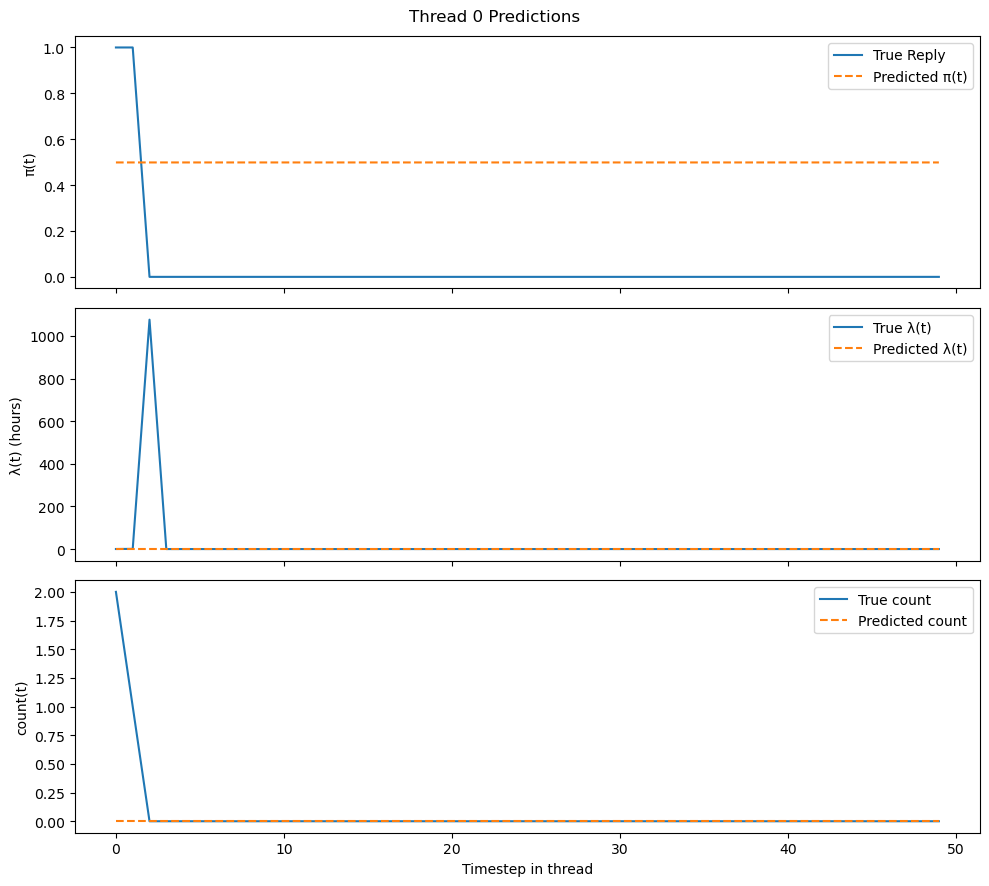

In [4]:
# Reload best model and visualize prediction for one thread
model.load_state_dict(torch.load("best_multitask_model.pt"))
model.eval()
visualize_predictions(model, X_val, t_val, y_val, lambda_val, count_val, thread_idx=0)

In [5]:
# Export all predictions
mask_val = (X_val.sum(-1) != 0)
export_predictions(model, X_val, t_val, mask_val, filename="predictions.csv")


✅ Exported predictions to predictions.csv


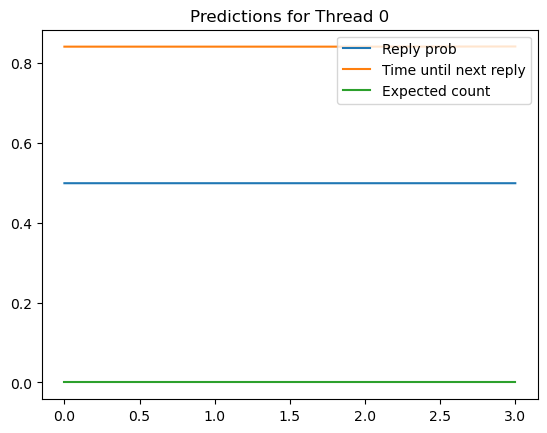

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

predictions_df = pd.read_csv("predictions.csv")
sample = predictions_df[predictions_df.thread_id == 0]

plt.plot(sample['π(t)'], label='Reply prob')
plt.plot(sample['λ(t)'], label='Time until next reply')
plt.plot(sample['count(t)'], label='Expected count')
plt.title("Predictions for Thread 0")
plt.legend()
plt.show()


In [7]:
import pandas as pd

# Ensure all tensors are on CPU and converted to numpy
comparison_data = []

# Build mask from X_val to skip padded entries
mask_val = (X_val.sum(-1) != 0)

for i in range(X_val.shape[0]):  # thread_id
    for j in range(X_val.shape[1]):  # step in thread
        if not mask_val[i, j]:
            continue
        comparison_data.append({
            'thread_id': i,
            'step': j,
            'π(t)_pred': predictions_df.loc[len(comparison_data), 'π(t)'],
            'π(t)_true': float(y_val[i, j].cpu()),
            'λ(t)_pred': predictions_df.loc[len(comparison_data), 'λ(t)'],
            'λ(t)_true': float(lambda_val[i, j].cpu()),
            'count(t)_pred': predictions_df.loc[len(comparison_data), 'count(t)'],
            'count(t)_true': float(count_val[i, j].cpu()),
        })

comparison_df = pd.DataFrame(comparison_data)

# Save or inspect
comparison_df.to_csv("comparison_report.csv", index=False)
comparison_df.head()


,thread_id,step,π(t)_pred,π(t)_true,λ(t)_pred,λ(t)_true,count(t)_pred,count(t)_true
0,0,0,0.498780,1.0,0.840612,0.248889,0.0,2.0
1,0,1,0.498780,1.0,0.840612,0.909444,0.0,1.0
2,0,2,0.498780,0.0,0.840612,1076.439697,0.0,0.0
3,0,3,0.498768,0.0,0.841048,0.000000,0.0,0.0
4,1,0,0.504003,0.0,0.932195,41.613888,0.0,0.0


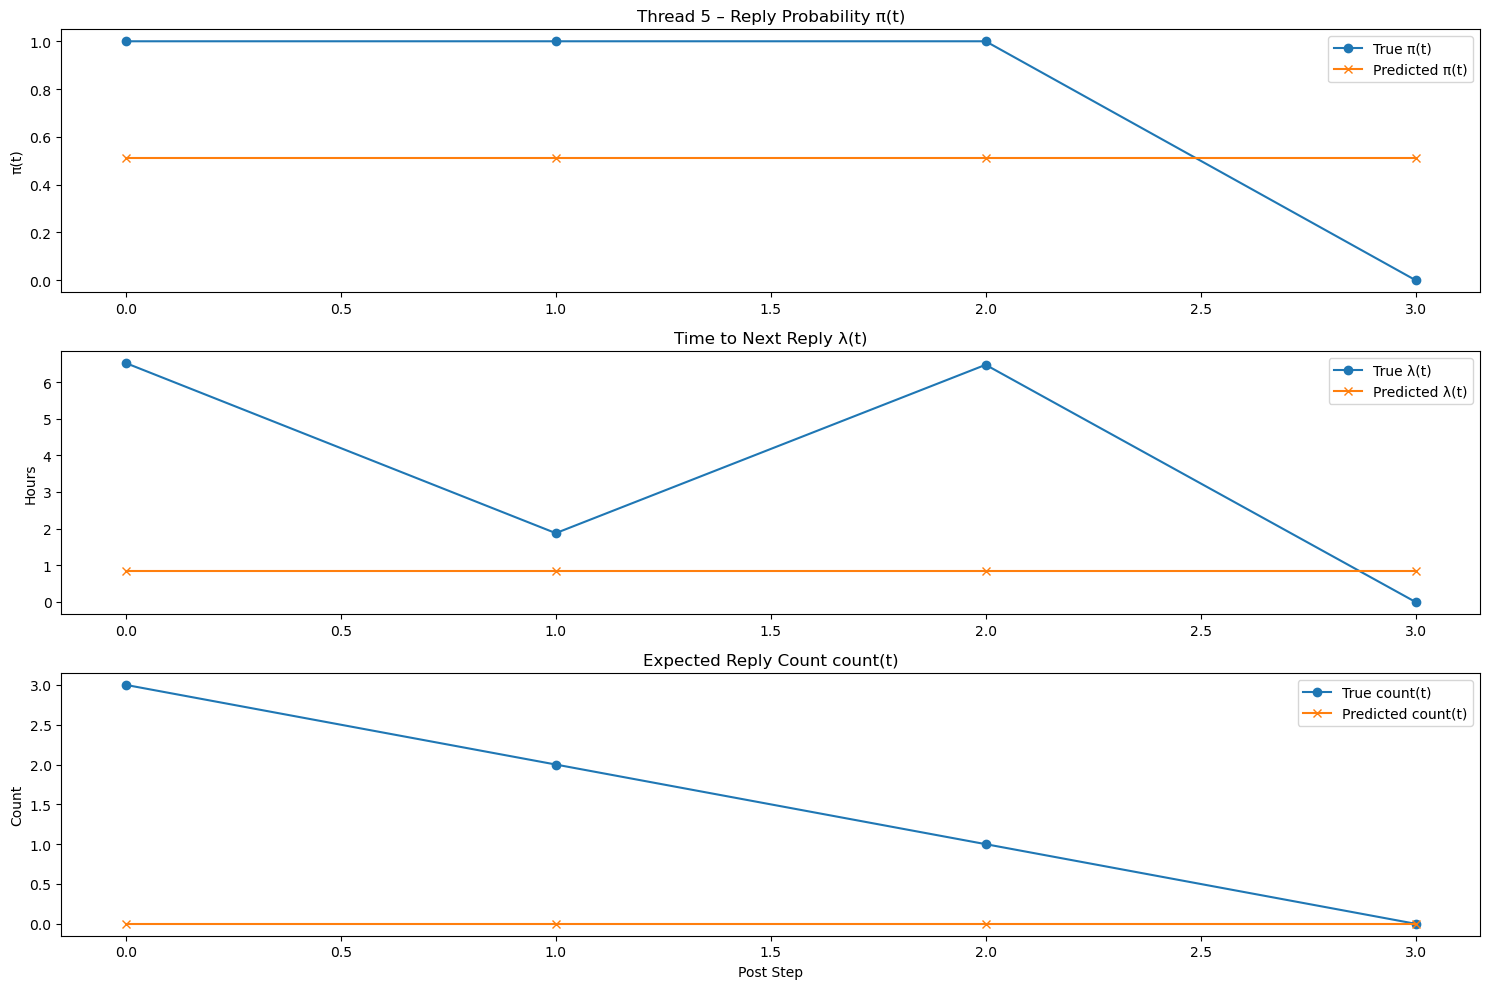

In [18]:
import matplotlib.pyplot as plt

def plot_predictions_for_thread(comparison_df, thread_id=0):
    df = comparison_df[comparison_df['thread_id'] == thread_id]

    plt.figure(figsize=(15, 10))

    # π(t)
    plt.subplot(3, 1, 1)
    plt.plot(df['step'], df['π(t)_true'], label='True π(t)', marker='o')
    plt.plot(df['step'], df['π(t)_pred'], label='Predicted π(t)', marker='x')
    plt.title(f"Thread {thread_id} – Reply Probability π(t)")
    plt.ylabel("π(t)")
    plt.legend()

    # λ(t)
    plt.subplot(3, 1, 2)
    plt.plot(df['step'], df['λ(t)_true'], label='True λ(t)', marker='o')
    plt.plot(df['step'], df['λ(t)_pred'], label='Predicted λ(t)', marker='x')
    plt.title("Time to Next Reply λ(t)")
    plt.ylabel("Hours")
    plt.legend()

    # count(t)
    plt.subplot(3, 1, 3)
    plt.plot(df['step'], df['count(t)_true'], label='True count(t)', marker='o')
    plt.plot(df['step'], df['count(t)_pred'], label='Predicted count(t)', marker='x')
    plt.title("Expected Reply Count count(t)")
    plt.xlabel("Post Step")
    plt.ylabel("Count")
    plt.legend()

    plt.tight_layout()
    plt.show()


plot_predictions_for_thread(comparison_df, thread_id=5)
